In [1]:
import numpy as np
import torch
from torch.utils.data import DataLoader
import os
import sys
import matplotlib.pyplot as plt

#CHANGE AS NEEDED
sys.path.append('/home/patrick/ansermodelling')
os.chdir("/home/patrick/ansermodelling")


from models.FFNN_network import FFNN
from data.anser_dataset import AnserDataset
from models.train import train
from data.anser_dataset import make_dataloaders

In [6]:
train_dataloader, test_dataloader = make_dataloaders("data/dataset.npz", train_frac = 0.8, batch_size = 32)

In [7]:
model = FFNN(input_dim=8, output_dim=5, hidden_dims=[64,256,64])
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [9]:
train_losses, test_losses = train(model, train_dataloader, test_dataloader, optimizer, epochs=100, print_losses = False)

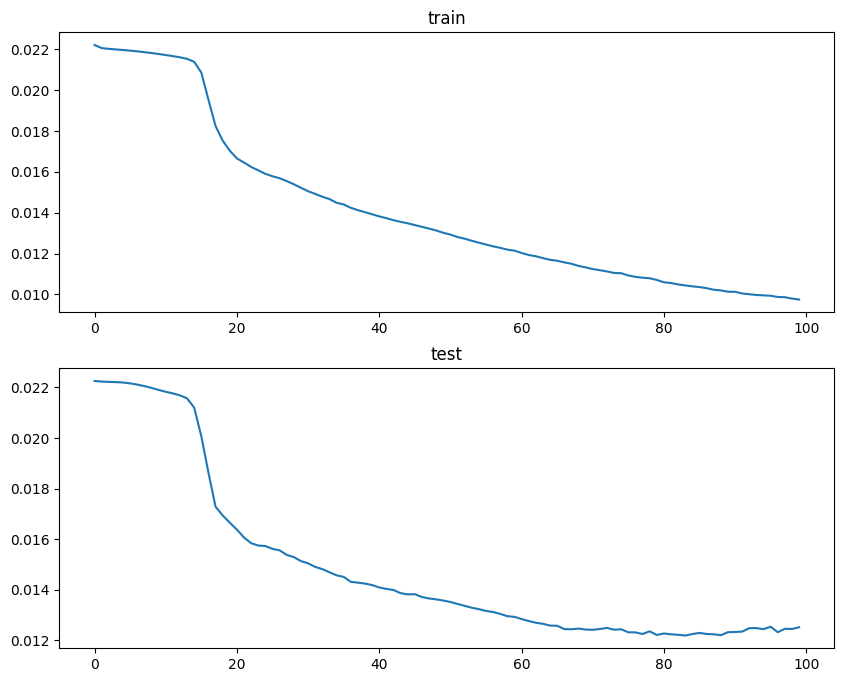

In [10]:
fig, axes = plt.subplots(2,figsize=(10, 8))
axes[0].plot(train_losses)
axes[0].set_title("train")
axes[1].plot(test_losses)
axes[1].set_title("test")
plt.show()
